In [ ]:
# ── MLOps bootstrap (auto-injected by inject_mlops_cell.py) ──────────────────
import os, warnings, mlflow
warnings.filterwarnings("ignore")

SEED = 42
import random, numpy as np
random.seed(SEED)
np.random.seed(SEED)
try:
    import torch; torch.manual_seed(SEED)
except ImportError:
    pass
try:
    import tensorflow as tf; tf.random.set_seed(SEED)
except ImportError:
    pass

_nb_name = os.path.basename(os.path.abspath("__file__") if "__file__" in dir() else ".").replace(".ipynb","")
mlflow.set_tracking_uri("sqlite:///" + str(Path(__file__).parent.parent.parent / "mlflow.db")
                        if "__file__" in dir() else "sqlite:///mlflow.db")
_exp = mlflow.set_experiment(_nb_name or "unnamed_notebook")
print(f"MLflow experiment: {_exp.name}")


# Standard Setup
This cell ensures **reproducibility**, **CUDA detection**, and proper **path management** across all notebooks in this monorepo.

In [ ]:
# ── Standard Setup Cell ──────────────────────────────────────
# Reproducibility | CUDA Detection | Path Management
import os
import random
import logging
from pathlib import Path

import numpy as np

# ── Reproducibility ─────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

# ── PyTorch + CUDA ──────────────────────────────────────────
try:
    import torch
    torch.manual_seed(SEED)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(SEED)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False
    DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"PyTorch {torch.__version__} | Device: {DEVICE}")
    if DEVICE.type == "cuda":
        print(f"  GPU: {torch.cuda.get_device_name(0)}")
except ImportError:
    DEVICE = "cpu"
    print("PyTorch not installed — using CPU")

# ── Paths (relative, portable) ──────────────────────────────
PROJECT_DIR = Path(".").resolve()
DATA_DIR = PROJECT_DIR / "data"
OUTPUT_DIR = PROJECT_DIR / "outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(f"Project : {PROJECT_DIR.name}")
print(f"Data    : {DATA_DIR}")

# ── Logging ─────────────────────────────────────────────────
logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s | %(levelname)-7s | %(message)s",
    datefmt="%H:%M:%S",
)
logger = logging.getLogger(__name__)

# Reinforcement Learning for Gridworld Navigation

In this tutorial, you are going to learn about the basic concepts in Reinforcement Learning (RL). 

## Roadmap

**1. Overview:** We will lay out the main topics RL is concerned with and introduce some basic terminology.
We will explore the connections between RL and other fields, where it comes from, and where it has been applied so far.
- Pavlov's classical conditioning
- Instrumental/operand conditioning
- Cognitive science (Decision-making, latent learning and the cognitive map)
- Artificial Intelligence (mostly game-playing)
- Engineering (mostly optimal control)

**3. Gridworlds:** We will discuss the general framework used to describe the learning and decision problems that arise when an intelligent *agent* gets to interact with an *environment* to reach a goal. 
This framework is called *Markov Decision Processes (MDPs)*. 
MDPs can be a bit abstract, so we'll introduce their simplest version (Finite MDPs) through the example of idealized navigation problems on a discrete grid.
We call these *Gridworlds*.

**4. Value Iteration and Dynamic Programming:** Before exploring how to solve MDPs *from trial and error*, we will briefly discuss the completely opposite problem: the agent already knows everything about the "mechanics" of the environment, e.g. its playing solitaire and it knows the rules. This is not much different from when *you* play solitaire. Only that the agent could in principle exactly simulate the evolution of the environment before taking any action and make the most rational decision possible given the rules of probability. However, even figuring out *how* to get what you want (when you actually know what you want) is already hard enough. This is usually referred to as the *optimal control problem* and can be seen as a subproblem of RL. We will discuss how to solve it effectively and efficiently.

**5. Reinforcement Learning:** In the most basic RL-setting, the agent usually doesn't know anything. Neighter does it know the mechincs of how the environment evolves, nor which outcome it wants. For certain outcomes, it receives a reward. Only the reward and the experienced outcomes give it some sense of which of these outcomes are valuable and which are not. Can the problem still be solved? Turnes out, in many cases, it can be solved perfectly. In fact, there are many ways to do so and some are better then others in a given cituation. We will specifically talk about:

- Monte Carlo Control, and
- Temporal Difference Learning

...and if you want to dive deeper, we will provide ressources for

- Deep Reinforcement Learning

**5. Your turn...** Now you have the chance to show what you have learned by finishing this algorithm.

## Gridworlds

### Setup

First we have to fetch some python code to visualize our environment.
We will work with simple gridworlds, because they are as straight-forward as it gets when it comes to visualizing the most important components of the RL problem.

You can safely ignore the next cell...

In [1]:
#This code adds specific directories and their subdirectories to the Python module search path,
#allowing the Python interpreter to find and import modules from those directories when needed.
import os
import sys
import numpy as np

tabular_methods_root_dir = './archive (1)/tabular-methods-master'

for pth in [
    tabular_methods_root_dir,
    os.path.join(tabular_methods_root_dir, "env"),
    os.path.join(tabular_methods_root_dir, "algorithms"),
    os.path.join(tabular_methods_root_dir, "utils"),
]:
    print(pth)
    if os.path.isdir(pth):
        print(f"Adding files to pythonpath: {pth}")
        print(f"==> {os.listdir(pth)}")
        sys.path.append(pth)

./archive (1)/tabular-methods-master
Adding files to pythonpath: ./archive (1)/tabular-methods-master
==> ['.gitignore', 'algorithms', 'data', 'doc', 'env', 'examples', 'LICENSE', 'README.md', 'requirements.txt', 'test', 'utils']
./archive (1)/tabular-methods-master\env
Adding files to pythonpath: ./archive (1)/tabular-methods-master\env
==> ['grid_world.py', '__pycache__']
./archive (1)/tabular-methods-master\algorithms
Adding files to pythonpath: ./archive (1)/tabular-methods-master\algorithms
==> ['dynamic_programming.py', 'temporal_difference.py', '__pycache__']
./archive (1)/tabular-methods-master\utils
Adding files to pythonpath: ./archive (1)/tabular-methods-master\utils
==> ['helper_functions.py', 'plots.py', '__pycache__']


### Introducing the gridworld

Lets first define a navigation problem in a 5x5 gridworld. The agent starts at some location (blue) and it has to navigate to a goal state (green). The gridworld has some obstructions (orange) and bad states (red).

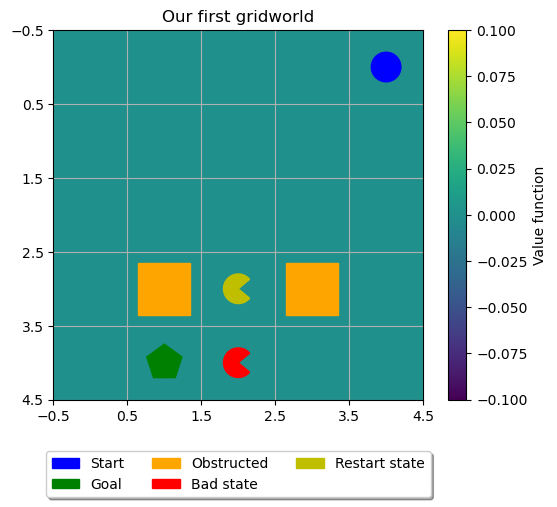

In [2]:
#This code sets up a grid world environment, defines its characteristics (such as start state, goal states, obstructions, 
#rewards, and transition probabilities), creates an MDP representation of the grid world, and then visualizes it using a plot.
from grid_world import GridWorld
from plots import plot_gridworld

num_rows = 5 
num_cols = 5 # represent the number of rows and columns in the grid.
start_state = np.array([[0, 4]]) # specifies the starting state as a numpy array.
goal_states = np.array([[4, 1]]) # specifies the goal states as a numpy array.
obstructions = np.array([[3,1],[3,3]])#specifies the obstructed states as a numpy array.
bad_states = np.array([[4,2]]) #specifies the bad states as a numpy array.
restart_states = np.array([[3,2]]) # specifies the restart states as a numpy array.

#It creates an instance of the GridWorld class called gw, passing the grid size, start state, and goal states as arguments.
gw = GridWorld(num_rows=num_rows,
               num_cols=num_cols,
               start_state=start_state,
               goal_states=goal_states) 
#It adds obstructions, bad states, and restart states to the grid world using the add_obstructions() method of the gw object.
gw.add_obstructions(obstructed_states=obstructions,
                    bad_states=bad_states,
                    restart_states=restart_states)
#It sets the step reward, goal reward, bad state reward, and restart state reward using the add_rewards() method of the gw object.
gw.add_rewards(step_reward=-1,
               goal_reward=10,
               bad_state_reward=-6,
               restart_state_reward=-100)
#it sets the transition probabilities for the grid world using the add_transition_probability() method of the gw object.
gw.add_transition_probability(p_good_transition=0.7,
                              bias=0.5)
#It sets the discount factor using the add_discount() method of the gw object.
gw.add_discount(discount=0.9)
#It creates the Markov Decision Process (MDP) for the grid world using the create_gridworld() method of the gw object and assigns it to the variable mdp.
mdp = gw.create_gridworld()
#It plots the grid world using the plot_gridworld() function, passing the mdp object and a title as arguments.
plot_gridworld(mdp, title="Our first gridworld")

Value iteration converged after 25 iterations.


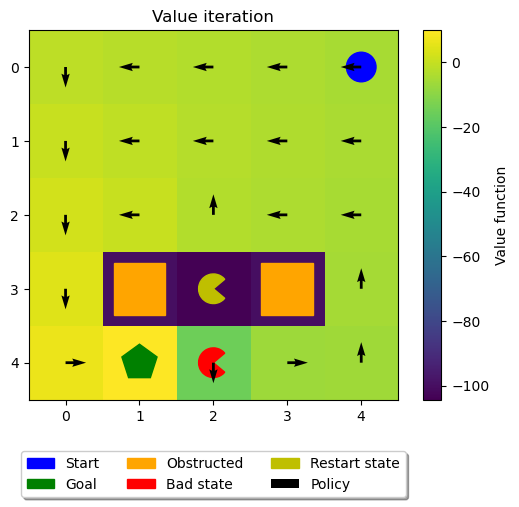

In [6]:
from dynamic_programming import value_iteration

# solve with value iteration
value_function, policy = value_iteration(mdp, maxiter=100)

# plot the results
plot_gridworld(mdp, value_function=value_function, policy=policy, title="Value iteration")